In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset
dataset = load_dataset("stanfordnlp/imdb")
print(dataset)

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


in this particular dataset there are about 25000 training examples and 25000 test examples giving the total of 50000 examples.

it uses about two classes to give the movie review i.e positive or negative for the entered movies.

In [ ]:
train_data = dataset['train']
test_data = dataset['test']
from transformers import AutoTokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess(example):
  return tokenizer(example['text'],truncation=True, padding=True ,max_length=512)

train_data = train_data.map(preprocess,batched=True)
test_data = test_data.map(preprocess,batched=True)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Tokenization converts the text value in the dataset in the numerical values so that the model can process it. we have to tune the distilBERT model on this dataset so we use the auto-tokenizer that cretes the numerical value of related texts acc to that model.

Truncation was needed so that the text examples that are larger than the maximum length of numerics generated for the model i.e values larger them max length of 512 can be laid off.

It helps the model to preprocess the data more effeciently to train it.


In [ ]:
from transformers import AutoModelForSequenceClassification
model = AutoModelForSequenceClassification.from_pretrained(model_name,num_labels=2)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


If we have set the 5 categories instead of two then the num_labels  values will change from 2 to 5. That means we then have 5 output classes instead of 2 that was labeled as yes or no.

In [ ]:
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

train_subset = train_data.shuffle(seed=42).select(range(3000))
eval_subset = test_data.shuffle(seed=42).select(range(500))

training_args = TrainingArguments(
    output_dir="./results_cleaned_improved",
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
)

def compute_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = np.argmax(logits, axis=-1)
  precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
  acc = accuracy_score(labels, predictions)
  return {
      'accuracy': acc,
      'precision': precision,
      'recall': recall,
      'f1': f1,
  }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_subset,
    eval_dataset=eval_subset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] # Stop if eval_loss doesn't improve for 3 evaluations
)

trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
200,0.134407,0.360304,0.890000,0.886640,0.890244,0.888438
400,0.074153,0.438752,0.892000,0.877953,0.906504,0.892000
564,0.034696,0.485788,0.890000,0.865900,0.918699,0.891519


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=564, training_loss=0.0953825407839836, metrics={'train_runtime': 618.1985, 'train_samples_per_second': 14.558, 'train_steps_per_second': 0.912, 'total_flos': 1192206587904000.0, 'train_loss': 0.0953825407839836, 'epoch': 3.0})

The model is overfitting as we can see the training loass in first epoch decrease then it increased in seconde epoch and in the third one it decreases to the large extent while the trend of validation loss changes in the same way at frist it decrease a little then it goes on increasing the bar.

Although the accuracy of the model goes to 90% the trend of validation loss and training loss shows that model is overfitting as it started learning the trends and will provide the prediction acc to its patterns that it already memorized.

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

new_review = "the plot was good and cast was very professional "
inputs = tokenizer(new_review, return_tensors="pt", truncation=True, padding=True, max_length=512)
inputs = {key: value.to(device) for key, value in inputs.items()}


outputs = model(**inputs)
predictions = torch.argmax(outputs.logits, dim=-1)
print("Positive" if predictions.item() == 1 else "Negative")

Positive


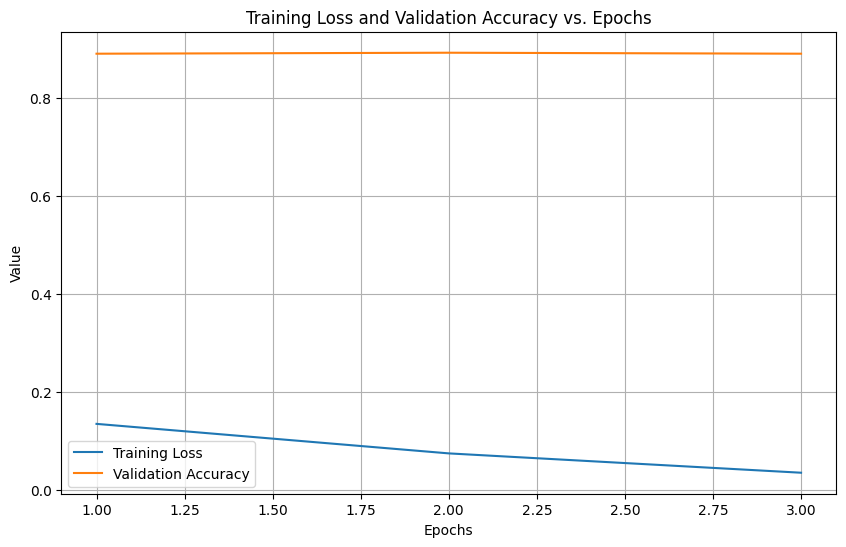

In [ ]:
import matplotlib.pyplot as plt
epochs = [1,2,3]
train_loss = [0.134407,0.074153,0.034696]
val_accuracy = [0.890000,0.892000,0.890000]

plt.figure(figsize=(10,6))
plt.plot(epochs,train_loss,label='Training Loss')
plt.plot(epochs,val_accuracy,label='Validation Accuracy')
plt.title('Training Loss and Validation Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
model.save_pretrained("./results_cleaned_improved")
tokenizer.save_pretrained("./results_cleaned_improved")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./results_cleaned_improved/tokenizer_config.json',
 './results_cleaned_improved/tokenizer.json')